Index(['sigma', 'freq', 'R'], dtype='object')
Resonance: 300.4 GHz, R_dark = 0.205


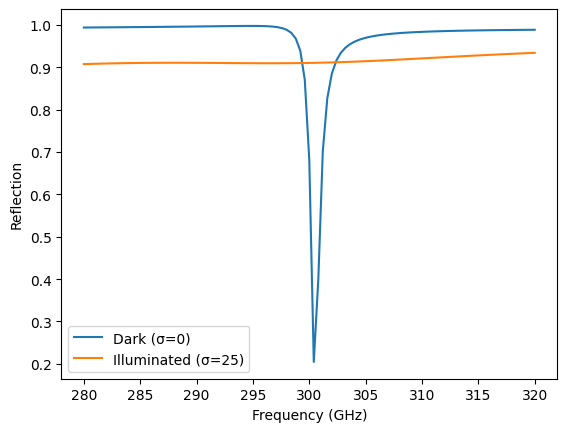

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the file
data = pd.read_csv("TE-R-whole.csv")

# 2. Rename the messy HFSS headers to simple names
data.columns = ["sigma", "freq", "R"]

# 3. Confirm it worked
print(data.columns)

# 4. Pull out dark (sigma=0) and illuminated (sigma=25) states
dark  = data[data["sigma"] == 0]
illum = data[data["sigma"] == 25]

# 5. Find resonance = minimum reflection in the dark state
idx   = dark["R"].idxmin()
f_res = dark["freq"][idx]
r_dark = dark["R"][idx]
print(f"Resonance: {f_res:.1f} GHz, R_dark = {r_dark:.3f}")

# 6. Plot both states
plt.plot(dark["freq"],  dark["R"],  label="Dark (σ=0)")
plt.plot(illum["freq"], illum["R"], label="Illuminated (σ=25)")
plt.xlabel("Frequency (GHz)")
plt.ylabel("Reflection")
plt.legend()
plt.show()

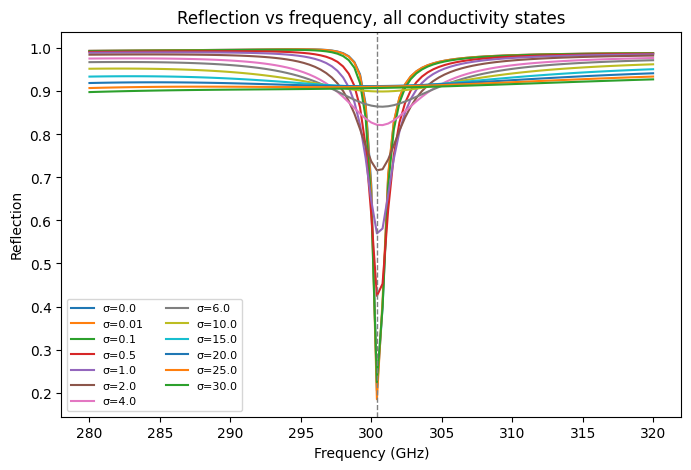

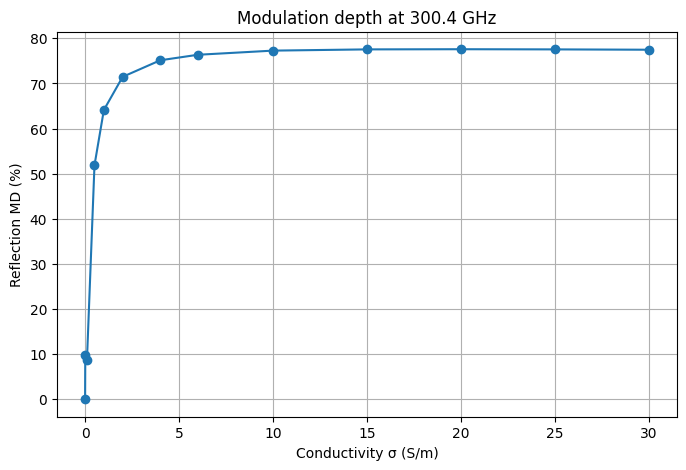

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("TE-R-whole.csv")
data.columns = ["sigma", "freq", "R"]

# Resonance from the dark state (sigma = 0)
dark = data[data["sigma"] == 0]
idx = dark["R"].idxmin()
f_res = dark["freq"][idx]
r_dark = dark["R"][idx]

# --- Figure 1: all reflection curves overlaid ---
plt.figure(figsize=(8,5))
for s in sorted(data["sigma"].unique()):
    sub = data[data["sigma"] == s]
    plt.plot(sub["freq"], sub["R"], label=f"σ={s}")
plt.axvline(f_res, color="gray", linestyle="--", linewidth=1)  # mark resonance
plt.xlabel("Frequency (GHz)")
plt.ylabel("Reflection")
plt.title("Reflection vs frequency, all conductivity states")
plt.legend(fontsize=8, ncol=2)
plt.show()

# --- Figure 2: modulation depth vs sigma at resonance ---
sigmas, mds = [], []
for s in sorted(data["sigma"].unique()):
    r = data[(data["sigma"] == s) & (data["freq"] == f_res)]["R"].values[0]
    md = abs(r - r_dark) / max(r, r_dark) * 100
    sigmas.append(s)
    mds.append(md)

plt.figure(figsize=(8,5))
plt.plot(sigmas, mds, "o-")
plt.xlabel("Conductivity σ (S/m)")
plt.ylabel("Reflection MD (%)")
plt.title(f"Modulation depth at {f_res:.1f} GHz")
plt.grid(True)
plt.show()

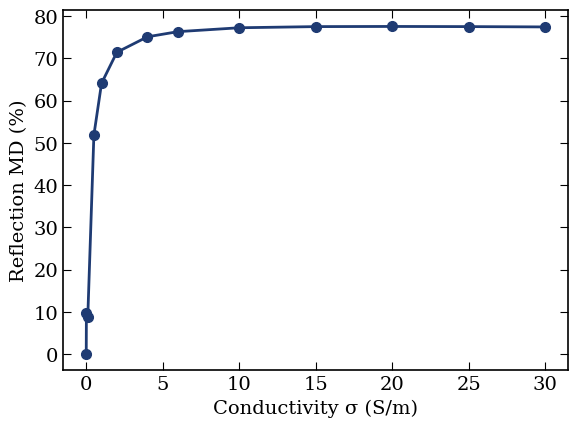

Saved MD_vs_sigma.png and .pdf


In [4]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_csv("TE-R-whole.csv")
data.columns = ["sigma", "freq", "R"]

dark = data[data["sigma"] == 0]
idx = dark["R"].idxmin()
f_res = dark["freq"][idx]
r_dark = dark["R"][idx]

# Build the MD-vs-sigma data
sigmas, mds = [], []
for s in sorted(data["sigma"].unique()):
    r = data[(data["sigma"] == s) & (data["freq"] == f_res)]["R"].values[0]
    mds.append(abs(r - r_dark) / max(r, r_dark) * 100)
    sigmas.append(s)

# Journal styling
plt.rcParams.update({
    "font.size": 14,
    "font.family": "serif",
    "axes.linewidth": 1.2,
    "lines.linewidth": 2,
})

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.plot(sigmas, mds, "o-", color="#1f3b73", markersize=7)
ax.set_xlabel("Conductivity σ (S/m)")
ax.set_ylabel("Reflection MD (%)")
ax.tick_params(direction="in", length=6, top=True, right=True)  # ticks inward, all sides
fig.tight_layout()

# Save at high resolution — both formats
fig.savefig("MD_vs_sigma.png", dpi=300, bbox_inches="tight")
fig.savefig("MD_vs_sigma.pdf", bbox_inches="tight")  # vector, for LaTeX
plt.show()
print("Saved MD_vs_sigma.png and .pdf")
